In [ ]:
# -*- coding: utf-8 -*-
from Library import utils, dataset
import os
import tensorflow as tf
from tensorflow import keras
from tqdm import tqdm
import numpy as np
from datetime import datetime
import logging
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import json

# ==============================================================================
# 1. SETUP VISUALISASI PERBANDINGAN DOMAIN ADAPTATION
# ==============================================================================
def plot_domain_adaptation_results(y_true, y_pred_before, y_pred_after, save_dir):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Matriks Sebelum Adaptasi (Baseline)
    cm_before = confusion_matrix(y_true, y_pred_before, labels=[0, 1])
    sns.heatmap(cm_before, annot=True, fmt='d', cmap='Reds', ax=axes[0], 
                annot_kws={"size": 14, "weight": "bold"})
    axes[0].set_title('STEAD 3C Baseline\n(Global UUSS - Biased)', fontweight='bold')
    axes[0].set_xlabel('Prediksi Model', fontweight='bold')
    axes[0].set_ylabel('Aktual', fontweight='bold')
    axes[0].set_xticklabels(['Noise', 'Gempa'])
    axes[0].set_yticklabels(['Noise', 'Gempa'])

    # Matriks Sesudah Adaptasi (Feature-Space Planes / Linear Planes)
    cm_after = confusion_matrix(y_true, y_pred_after, labels=[0, 1])
    sns.heatmap(cm_after, annot=True, fmt='d', cmap='Greens', ax=axes[1],
                annot_kws={"size": 14, "weight": "bold"})
    axes[1].set_title('STEAD 3C Sesudah Adaptasi\n(Feature-Space Planes / FPS)', fontweight='bold')
    axes[1].set_xlabel('Prediksi Model', fontweight='bold')
    axes[1].set_ylabel('Aktual', fontweight='bold')
    axes[1].set_xticklabels(['Noise', 'Gempa'])
    axes[1].set_yticklabels(['Noise', 'Gempa'])

    plt.tight_layout()
    cm_path = os.path.join(save_dir, "stead_3c_fps_confusion_comparison.jpg")
    plt.savefig(cm_path, dpi=300)
    plt.close()
    print(f"[INFO] Grafik perbandingan matrix tersimpan di: {cm_path}")

# ==============================================================================
# MAIN EXECUTION
# ==============================================================================
if __name__ == "__main__":
    os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

    # ==============================================================================
    # 2. KONFIGURASI PATH & EKSPERIMEN
    # ==============================================================================
    KEY_DATA_DIR = '/Volumes/Extreme SSD/stream_stead/data_stead/stead_sample_5000'
    KEY_TEST_FILE = 'STEAD_5000_3C_20260719_062844.json'  
    DATA_TAG = "STEAD_5000_FPS_ADAPTATION"
    MODEL_TAG = "MCU_Quake_3C"
    INPUT_WIN = 7 
    SAMPLING_RATE = 100
    
    CALIBRATION_SIZE = 500  # Jumlah sampel kalibrasi untuk mencari bidang batas keputusan

    BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo"
    MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")
    EMB_DIR = os.path.join(BASE_REP, "Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909")

    # ==============================================================================
    # 3. DIREKTORI OUTPUT & LOGGER
    # ==============================================================================
    print(f"[INFO] Memuat Dataset STEAD 5000 untuk Feature-Space Planes Adaptation: {KEY_TEST_FILE}")
    test_data = dataset.load_json_data(os.path.join(KEY_DATA_DIR, KEY_TEST_FILE))
    
    SAVE_BASE = '/Volumes/Extreme SSD/stream_stead/data_stead/benchmark_stead_5000_3c_fps'
    time_str = datetime.now().strftime("%d%H%M%S")
    save_dir = os.path.join(SAVE_BASE, f"{MODEL_TAG}_{DATA_TAG}_{time_str}")
    os.makedirs(save_dir, exist_ok=True)

    logging.basicConfig(filename=os.path.join(save_dir, "task_log_stead_fps.txt"), level=logging.INFO, filemode='w',
                        format='%(asctime)s - [%(levelname)s]: %(message)s')
    logger = logging.getLogger()
    logger.addHandler(logging.StreamHandler())

    # ==============================================================================
    # 4. BYPASS MODEL LOADING & EKSTRAKTOR FITUR BEKU (FROZEN)
    # ==============================================================================
    logger.info("Memuat model menggunakan bypass tf.saved_model.load (Frozen Feature Extractor)...")
    model_wrapper = tf.saved_model.load(MODEL_PATH)
    infer = model_wrapper.signatures['serving_default']
    
    class SavedModelWrapper:
        def __call__(self, x, *args, **kwargs):
            tensor_x = tf.convert_to_tensor(x, dtype=tf.float32)
            results = infer(tensor_x)
            return tf.convert_to_tensor(list(results.values())[0])

        def predict(self, x, *args, **kwargs):
            return self.__call__(x).numpy()

    embedding_model = SavedModelWrapper()
    
    # Load Embedding Global UUSS untuk Referensi Baseline
    embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
    embedding_N = dataset.load_embedding_data(EMB_DIR, "Embedding data, N.json")
    embedding_E = dataset.load_embedding_data(EMB_DIR, "Embedding data, E.json")
    embeddings_3C_PDFs = utils.embedding_PDFs_3D(embedding_Z, embedding_N, embedding_E)

    # ==============================================================================
    # 5. SPLIT DATA & KALIBRASI FEATURE-SPACE PLANES (FPS)
    # ==============================================================================
    keys_list = list(test_data.keys())
    np.random.seed(42)
    np.random.shuffle(keys_list)

    calibration_keys = keys_list[:CALIBRATION_SIZE]
    test_keys = keys_list[CALIBRATION_SIZE:]

    logger.info(f"Menggunakan {len(calibration_keys)} sampel untuk Kalibrasi Decision Planes (Unsupervised/Pseudo-Labeling)...")
    num_points = int(INPUT_WIN * SAMPLING_RATE)
    
    X_calib_features = []
    y_calib_labels = []

    for key in tqdm(calibration_keys, desc="Ekstraksi Fitur Laten Kalibrasi STEAD"):
        rec = test_data[key]
        
        # Ekstraksi Noise (Label 0)
        zn = np.array(rec["Z_noise"][-num_points:], dtype=np.float32)
        nn = np.array(rec["N_noise"][-num_points:], dtype=np.float32)
        en = np.array(rec["E_noise"][-num_points:], dtype=np.float32)
        _in_zn = utils.latent_codes_1D(zn, embedding_model)
        _in_nn = utils.latent_codes_1D(nn, embedding_model)
        _in_en = utils.latent_codes_1D(en, embedding_model)
        feat_n = np.concatenate([_in_en, _in_nn, _in_zn]) # Flatten 3C latent vector
        X_calib_features.append(feat_n)
        y_calib_labels.append(0)

        # Ekstraksi Gempa/Signal (Label 1)
        zs = np.array(rec["Z"][:num_points], dtype=np.float32)
        ns = np.array(rec["N"][:num_points], dtype=np.float32)
        es = np.array(rec["E"][:num_points], dtype=np.float32)
        _in_zs = utils.latent_codes_1D(zs, embedding_model)
        _in_ns = utils.latent_codes_1D(ns, embedding_model)
        _in_es = utils.latent_codes_1D(es, embedding_model)
        feat_s = np.concatenate([_in_es, _in_ns, _in_zs])
        X_calib_features.append(feat_s)
        y_calib_labels.append(1)

    X_calib = np.array(X_calib_features)
    y_calib = np.array(y_calib_labels)

    # Mengoptimalkan Bidang Batas Keputusan (Decision Planes) menggunakan Linear Classifier (Closed-Form / SVM / Logistic)
    logger.info("Mengoptimalkan Feature-Space Planes (Decision Boundary Adjustment)...")
    decision_plane_model = LogisticRegression(C=1.0, solver='liblinear', random_state=42)
    decision_plane_model.fit(X_calib, y_calib)
    logger.info("✅ Feature-Space Decision Planes berhasil disesuaikan pada domain STEAD!")

    # ==============================================================================
    # 6. EVALUASI DAN KOMPARASI (SEBELUM VS SESUDAH ADAPTASI FPS)
    # ==============================================================================
    y_true = []
    y_pred_before = []  # Baseline UUSS (KDE Global)
    y_pred_after = []   # Adaptasi Feature-Space Planes (FPS)

    logger.info(f"Menjalankan evaluasi komparatif pada {len(test_keys)} data uji...")

    for key in tqdm(test_keys, desc="Inferensi Test Set STEAD (FPS DA)"):
        rec = test_data[key]
        
        # ---------------------------------------------------------
        # UJI NOISE (Aktual = 0)
        # ---------------------------------------------------------
        zn = np.array(rec["Z_noise"][-num_points:], dtype=np.float32)
        nn = np.array(rec["N_noise"][-num_points:], dtype=np.float32)
        en = np.array(rec["E_noise"][-num_points:], dtype=np.float32)

        _in_zn = utils.latent_codes_1D(zn, embedding_model)
        _in_nn = utils.latent_codes_1D(nn, embedding_model)
        _in_en = utils.latent_codes_1D(en, embedding_model)
        emb_n = np.array([_in_en, _in_nn, _in_zn]).reshape(3, -1)
        feat_n_flat = np.concatenate([_in_en, _in_nn, _in_zn]).reshape(1, -1)

        # Baseline Sebelum Adaptasi (KDE Global UUSS)
        p_n_global, _, _ = utils.infer_3C_PDFs(emb_n.T, embeddings_3C_PDFs, "Kernel")
        y_pred_before.append(1 if p_n_global >= 1 else 0)

        # Sesudah Adaptasi (Feature-Space Planes / FPS)
        pred_fps_n = decision_plane_model.predict(feat_n_flat)[0]
        y_pred_after.append(int(pred_fps_n))
        
        y_true.append(0)

        # ---------------------------------------------------------
        # UJI GEMPA / SIGNAL (Aktual = 1)
        # ---------------------------------------------------------
        zs = np.array(rec["Z"][:num_points], dtype=np.float32)
        ns = np.array(rec["N"][:num_points], dtype=np.float32)
        es = np.array(rec["E"][:num_points], dtype=np.float32)

        _in_zs = utils.latent_codes_1D(zs, embedding_model)
        _in_ns = utils.latent_codes_1D(ns, embedding_model)
        _in_es = utils.latent_codes_1D(es, embedding_model)
        emb_s = np.array([_in_es, _in_ns, _in_zs]).reshape(3, -1)
        feat_s_flat = np.concatenate([_in_es, _in_ns, _in_zs]).reshape(1, -1)

        # Baseline Sebelum Adaptasi (KDE Global UUSS)
        p_s_global, _, _ = utils.infer_3C_PDFs(emb_s.T, embeddings_3C_PDFs, "Kernel")
        y_pred_before.append(1 if p_s_global >= 1 else 0)

        # Sesudah Adaptasi (Feature-Space Planes / FPS)
        pred_fps_s = decision_plane_model.predict(feat_s_flat)[0]
        y_pred_after.append(int(pred_fps_s))
        
        y_true.append(1)

    # ==============================================================================
    # 7. PERHITUNGAN METRIK & PENYIMPANAN
    # ==============================================================================
    def calculate_metrics(yt, yp):
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
        f1 = 2 * (ppv * tpr) / (ppv + tpr) if (ppv + tpr) > 0 else 0
        acc = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
        return {
            "Accuracy": float(acc), "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp), 
            "TPR": float(tpr), "FPR": float(fpr), "PPV": float(ppv), "F1": float(f1)
        }

    met_before = calculate_metrics(y_true, y_pred_before)
    met_after = calculate_metrics(y_true, y_pred_after)

    logger.info("\n" + "="*50)
    logger.info("HASIL EVALUASI FEATURE-SPACE PLANES (STEAD 5000 3C)")
    logger.info("="*50)
    logger.info(f"SEBELUM Adaptasi (Baseline UUSS):")
    logger.info(f" - Akurasi : {met_before['Accuracy']*100:.2f}% | F1: {met_before['F1']:.3f}")
    logger.info(f" - TPR (Sensitivity) : {met_before['TPR']*100:.2f}%")
    logger.info(f" - FPR (Alarm Palsu) : {met_before['FPR']*100:.2f}%")

    logger.info(f"\nSESUDAH Adaptasi (Feature-Space Planes / FPS):")
    logger.info(f" - Akurasi : {met_after['Accuracy']*100:.2f}% | F1: {met_after['F1']:.3f}")
    logger.info(f" - TPR (Sensitivity) : {met_after['TPR']*100:.2f}%")
    logger.info(f" - FPR (Alarm Palsu) : {met_after['FPR']*100:.2f}%")
    logger.info("="*50)

    # Simpan Hasil JSON dan Plot
    with open(os.path.join(save_dir, "stead_fps_comparison_results.json"), 'w') as f:
        json.dump({"before_adaptation": met_before, "after_adaptation": met_after}, f, indent=4)

    plot_domain_adaptation_results(y_true, y_pred_before, y_pred_after, save_dir)
    logger.info(f"Eksperimen Feature-Space Planes STEAD selesai. Output tersimpan di: {save_dir}")

In [ ]:
# -*- coding: utf-8 -*-
from Library import utils, dataset
import os
import tensorflow as tf
from tensorflow import keras
from tqdm import tqdm
import numpy as np
from datetime import datetime
import logging
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import json

# [Fungsi plot_comprehensive_metrics dan plot_domain_adaptation_results tetap sama]
# ... (Masukkan fungsi plot Anda di sini) ...

# ==============================================================================
# MAIN EXECUTION (KOREKSI)
# ==============================================================================
if __name__ == "__main__":
    os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

    # Path & Konfigurasi
    KEY_DATA_DIR = '/Volumes/Extreme SSD/stream_stead/data_stead/stead_sample_5000'
    KEY_TEST_FILE = 'STEAD_5000_1C_CLEAN.json'  # File JSON uji STEAD 1C
    
    # ... (Path konfigurasi lainnya tetap)

    test_data = dataset.load_json_data(os.path.join(KEY_DATA_DIR, KEY_TEST_FILE))
    
    # Memuat Model
    embedding_model = keras.models.load_model(MODEL_PATH)
    embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
    embeddings_1C_PDFs = embedding_Z 

    keys_list = list(test_data.keys())
    np.random.seed(42)
    np.random.shuffle(keys_list)
    
    # Split
    calibration_keys = keys_list[:500]
    test_keys = keys_list[500:]

    # 5. KALIBRASI FPS (Decision Planes)
    X_calib, y_calib = [], []
    num_points = 700

    logger.info("Mengekstraksi fitur kalibrasi...")
    for key in tqdm(calibration_keys):
        rec = test_data[key]
        # Noise
        if "Z_noise" in rec and len(rec["Z_noise"]) >= num_points:
            feat_n = np.array(utils.latent_codes_1D(np.array(rec["Z_noise"][-num_points:]), embedding_model)).flatten()
            X_calib.append(feat_n)
            y_calib.append(0)
        # Gempa
        if "Z" in rec and len(rec["Z"]) >= num_points:
            feat_s = np.array(utils.latent_codes_1D(np.array(rec["Z"][:num_points]), embedding_model)).flatten()
            X_calib.append(feat_s)
            y_calib.append(1)

    decision_plane_model = LogisticRegression(C=0.1, solver='liblinear', class_weight='balanced')
    decision_plane_model.fit(np.array(X_calib), np.array(y_calib))
    
    # 6. EVALUASI (Loop yang disinkronisasi)
    y_true, y_pred_before, y_pred_after = [], [], []

    logger.info("Menjalankan inferensi terkoreksi...")
    for key in tqdm(test_keys):
        rec = test_data[key]
        if not ("Z" in rec and "Z_noise" in rec): continue
        
        # Ekstraksi kedua sinyal
        zn = np.array(rec["Z_noise"][-num_points:])
        zs = np.array(rec["Z"][:num_points])
        
        # Prediksi Noise
        fn = np.array(utils.latent_codes_1D(zn, embedding_model)).flatten().reshape(1, -1)
        p_n_global, _, _ = utils.infer_1C_PDFs(fn, embeddings_1C_PDFs, "Kernel")
        
        y_true.append(0)
        y_pred_before.append(1 if p_n_global >= 1 else 0)
        y_pred_after.append(int(decision_plane_model.predict(fn)[0]))
        
        # Prediksi Gempa
        fs = np.array(utils.latent_codes_1D(zs, embedding_model)).flatten().reshape(1, -1)
        p_s_global, _, _ = utils.infer_1C_PDFs(fs, embeddings_1C_PDFs, "Kernel")
        
        y_true.append(1)
        y_pred_before.append(1 if p_s_global >= 1 else 0)
        y_pred_after.append(int(decision_plane_model.predict(fs)[0]))

    # [Lanjutkan dengan perhitungan metrik dan plot...]
    logger.info("Evaluasi Selesai.")

In [ ]:
# -*- coding: utf-8 -*-
from Library import utils, dataset
import os
import tensorflow as tf
from tensorflow import keras
from tqdm import tqdm
import numpy as np
from datetime import datetime
import logging
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import json

# ==============================================================================
# 1. SETUP VISUALISASI METRIK KOMPREHENSIF & CONFUSION MATRIX (1C)
# ==============================================================================
def plot_comprehensive_metrics(metrics, save_path):
    labels = ['Accuracy', 'Recall', 'Precision', 'FPR', 'F1-Score']
    keys = [
        'Accuracy (avg.)', 
        'True positive rate (avg.)', 
        'Positive predictive value (avg.)', 
        'False positive rate (avg.)', 
        'F1-score (avg.)'
    ]
    
    values = []
    for k in keys:
        if k in metrics:
            values.append(metrics[k])
        else:
            alt_map = {
                'Accuracy (avg.)': 'Accuracy', 
                'True positive rate (avg.)': 'TPR', 
                'Positive predictive value (avg.)': 'PPV', 
                'False positive rate (avg.)': 'FPR', 
                'F1-score (avg.)': 'F1'
            }
            alt_k = alt_map.get(k, k)
            values.append(metrics.get(alt_k, 0.0))
    
    print(f"[DEBUG] Nilai yang akan diplot: {values}") 

    plt.figure(figsize=(12, 6))
    bars = plt.bar(labels, values, color=['#2c3e50', '#3498db', '#e67e22', '#e74c3c', '#27ae60'])
    
    plt.ylim(0, 1.0)
    plt.ylabel('Score')
    plt.title('Performance Metrics Evaluation (Feature-Space Planes / FPS 1C)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom')
                
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()
    print(f"[INFO] Grafik metrik komprehensif tersimpan di: {save_path}")

def plot_domain_adaptation_results(y_true, y_pred_before, y_pred_after, save_dir):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Matriks Sebelum Adaptasi (Baseline 1C)
    cm_before = confusion_matrix(y_true, y_pred_before, labels=[0, 1])
    sns.heatmap(cm_before, annot=True, fmt='d', cmap='Reds', ax=axes[0], 
                annot_kws={"size": 14, "weight": "bold"})
    axes[0].set_title('STEAD 1C Baseline\n(Global UUSS 1C - Biased)', fontweight='bold')
    axes[0].set_xlabel('Prediksi Model', fontweight='bold')
    axes[0].set_ylabel('Aktual', fontweight='bold')
    axes[0].set_xticklabels(['Noise', 'Gempa'])
    axes[0].set_yticklabels(['Noise', 'Gempa'])

    # Matriks Sesudah Adaptasi (Feature-Space Planes 1C)
    cm_after = confusion_matrix(y_true, y_pred_after, labels=[0, 1])
    sns.heatmap(cm_after, annot=True, fmt='d', cmap='Greens', ax=axes[1],
                annot_kws={"size": 14, "weight": "bold"})
    axes[1].set_title('STEAD 1C Sesudah Adaptasi\n(Feature-Space Planes / FPS 1C)', fontweight='bold')
    axes[1].set_xlabel('Prediksi Model', fontweight='bold')
    axes[1].set_ylabel('Aktual', fontweight='bold')
    axes[1].set_xticklabels(['Noise', 'Gempa'])
    axes[1].set_yticklabels(['Noise', 'Gempa'])

    plt.tight_layout()
    cm_path = os.path.join(save_dir, "stead_1c_fps_confusion_comparison.jpg")
    plt.savefig(cm_path, dpi=300)
    plt.close()
    print(f"[INFO] Grafik perbandingan matrix tersimpan di: {cm_path}")

# ==============================================================================
# MAIN EXECUTION
# ==============================================================================
if __name__ == "__main__":
    os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

    # ==============================================================================
    # 2. KONFIGURASI PATH & EKSPERIMEN STEAD (1C)
    # ==============================================================================
    KEY_DATA_DIR = '/Volumes/Extreme SSD/stream_stead/data_stead/stead_sample_5000'
    KEY_TEST_FILE = 'STEAD_5000_1C_CLEAN.json'  
    
    DATA_TAG = "STEAD_5000_1C_FPS_ADAPTATION"
    MODEL_TAG = "MCU_5-20"
    INPUT_WIN = 7 
    SAMPLING_RATE = 100
    
    CALIBRATION_SIZE = 500  # Jumlah sampel kalibrasi untuk penyesuaian decision planes (FPS)

    BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo"
    MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")
    EMB_DIR = os.path.join(BASE_REP, "Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909")

    # ==============================================================================
    # 3. DIREKTORI OUTPUT & LOGGER
    # ==============================================================================
    print(f"[INFO] Memuat Dataset STEAD 1C: {KEY_TEST_FILE}")
    test_data = dataset.load_json_data(os.path.join(KEY_DATA_DIR, KEY_TEST_FILE))
    
    SAVE_BASE = '/Volumes/Extreme SSD/stream_stead/data_stead/benchmark_stead_5000_1c_fps'
    now = datetime.now()
    time_str = now.strftime("%d%H%M%S")
    save_dir = os.path.join(SAVE_BASE, f"{MODEL_TAG}_{DATA_TAG}_{time_str}")
    os.makedirs(save_dir, exist_ok=True)

    log_file_path = os.path.join(save_dir, "task_log_stead_fps.txt")
    logging.basicConfig(filename=log_file_path, level=logging.INFO, filemode='w',
                        format='%(asctime)s - [%(levelname)s]: %(message)s')
    logger = logging.getLogger()
    logger.addHandler(logging.StreamHandler())

    # ==============================================================================
    # 4. MEMUAT MODEL (FROZEN FEATURE EXTRACTOR) & EMBEDDINGS 1C
    # ==============================================================================
    logger.info(f"Memuat model pre-trained Keras dari: {MODEL_PATH}")
    embedding_model = keras.models.load_model(filepath=MODEL_PATH)

    embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
    embeddings_1C_PDFs = embedding_Z  # Referensi PDF komponen vertikal Z

    # ==============================================================================
    # 5. SPLIT DATA & KALIBRASI FEATURE-SPACE PLANES (FPS) 1C
    # ==============================================================================
    keys_list = list(test_data.keys())
    np.random.seed(42)
    np.random.shuffle(keys_list)

    calibration_keys = keys_list[:CALIBRATION_SIZE]
    test_keys = keys_list[CALIBRATION_SIZE:]

    logger.info(f"Menggunakan {len(calibration_keys)} sampel untuk Kalibrasi Decision Planes 1C (Unsupervised)...")
    num_points = int(INPUT_WIN * SAMPLING_RATE)
    
    X_calib_features = []
    y_calib_labels = []

    for key in tqdm(calibration_keys, desc="Ekstraksi Fitur Laten Kalibrasi STEAD 1C"):
        record = test_data[key]
        try:
            if not all(k in record for k in ["Z_noise", "Z"]):
                continue

            # Ekstraksi Noise 1C (Label 0)
            zn = np.array(record["Z_noise"][-num_points:], dtype=np.float32)
            if len(zn) < num_points:
                continue
            _in_zn = utils.latent_codes_1D(zn, embedding_model)
            feat_n = np.array(_in_zn).flatten()
            X_calib_features.append(feat_n)
            y_calib_labels.append(0)

            # Ekstraksi Gempa/Signal 1C (Label 1)
            zs = np.array(record["Z"][:num_points], dtype=np.float32)
            if len(zs) < num_points:
                continue
            _in_zs = utils.latent_codes_1D(zs, embedding_model)
            feat_s = np.array(_in_zs).flatten()
            X_calib_features.append(feat_s)
            y_calib_labels.append(1)
        except Exception as e:
            continue

    X_calib = np.array(X_calib_features)
    y_calib = np.array(y_calib_labels)

    # Mengoptimalkan Bidang Batas Keputusan (Decision Planes) dengan Logistic Regression Seimbang
    logger.info("Mengoptimalkan Feature-Space Decision Planes (FPS) 1C...")
    decision_plane_model = LogisticRegression(C=0.1, solver='liblinear', class_weight='balanced', random_state=42)
    decision_plane_model.fit(X_calib, y_calib)
    logger.info("✅ Feature-Space Decision Planes 1C berhasil disesuaikan pada domain STEAD!")

    # ==============================================================================
    # 6. EVALUASI KOMPARATIF (SEBELUM VS SESUDAH ADAPTASI FPS 1C)
    # ==============================================================================
    y_true = []
    y_pred_before = []  # Baseline UUSS 1C (KDE Global 1C)
    y_pred_after = []   # Adaptasi Feature-Space Planes 1C (FPS)

    logger.info(f"Menjalankan evaluasi komparatif pada {len(test_keys)} data uji STEAD...")

    for key in tqdm(test_keys, desc="Inferensi Test Set STEAD 1C (FPS DA)"):
        record = test_data[key]
        try:
            if not all(k in record for k in ["Z_noise", "Z"]):
                continue

            # ---------------------------------------------------------
            # UJI NOISE 1C (Aktual = 0)
            # ---------------------------------------------------------
            zn = np.array(record["Z_noise"][-num_points:], dtype=np.float32)
            if len(zn) < num_points:
                continue
                
            _in_zn = utils.latent_codes_1D(zn, embedding_model)
            feat_n_flat = np.array(_in_zn).reshape(1, -1)
            
            # Baseline Sebelum Adaptasi (Menggunakan infer_1C_PDFs khusus 1C)
            p_n_global, _, _ = utils.infer_1C_PDFs(feat_n_flat, embeddings_1C_PDFs, "Kernel")
            y_pred_before.append(1 if p_n_global >= 1 else 0)

            # Sesudah Adaptasi (Feature-Space Planes / FPS 1C)
            pred_fps_n = decision_plane_model.predict(feat_n_flat)[0]
            y_pred_after.append(int(pred_fps_n))
            y_true.append(0)

            # ---------------------------------------------------------
            # UJI GEMPA / SIGNAL 1C (Aktual = 1)
            # ---------------------------------------------------------
            zs = np.array(record["Z"][:num_points], dtype=np.float32)
            if len(zs) < num_points:
                y_true.pop()
                y_pred_before.pop()
                y_pred_after.pop()
                continue

            _in_zs = utils.latent_codes_1D(zs, embedding_model)
            feat_s_flat = np.array(_in_zs).reshape(1, -1)

            p_s_global, _, _ = utils.infer_1C_PDFs(feat_s_flat, embeddings_1C_PDFs, "Kernel")
            y_pred_before.append(1 if p_s_global >= 1 else 0)

            # Sesudah Adaptasi (Feature-Space Planes / FPS 1C)
            pred_fps_s = decision_plane_model.predict(feat_s_flat)[0]
            y_pred_after.append(int(pred_fps_s))
            y_true.append(1)

        except Exception as e:
            continue

    if len(y_true) == 0:
        raise ValueError("Gagal total: Array `y_true` dan prediksi kosong! Periksa panjang data pada key Z_noise dan Z.")

    # ==============================================================================
    # 7. PERHITUNGAN METRIK & PENYIMPANAN
    # ==============================================================================
    def calculate_metrics(yt, yp):
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
        f1 = 2 * (ppv * tpr) / (ppv + tpr) if (ppv + tpr) > 0 else 0
        acc = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
        return {
            "Accuracy (avg.)": float(acc), "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp), 
            "True positive rate (avg.)": float(tpr), "False positive rate (avg.)": float(fpr), 
            "Positive predictive value (avg.)": float(ppv), "F1-score (avg.)": float(f1)
        }

    met_before = calculate_metrics(y_true, y_pred_before)
    met_after = calculate_metrics(y_true, y_pred_after)

    logger.info("\n" + "="*50)
    logger.info("HASIL EVALUASI FEATURE-SPACE PLANES (STEAD 1C)")
    logger.info("="*50)
    logger.info(f"SEBELUM Adaptasi (Baseline UUSS 1C):")
    logger.info(f" - Akurasi : {met_before['Accuracy (avg.)']*100:.2f}% | F1: {met_before['F1-score (avg.)']:.3f}")
    logger.info(f" - TPR (Sensitivity) : {met_before['True positive rate (avg.)']*100:.2f}%")
    logger.info(f" - FPR (Alarm Palsu) : {met_before['False positive rate (avg.)']*100:.2f}%")

    logger.info(f"\nSESUDAH Adaptasi (Feature-Space Planes / FPS 1C):")
    logger.info(f" - Akurasi : {met_after['Accuracy (avg.)']*100:.2f}% | F1: {met_after['F1-score (avg.)']:.3f}")
    logger.info(f" - TPR (Sensitivity) : {met_after['True positive rate (avg.)']*100:.2f}%")
    logger.info(f" - FPR (Alarm Palsu) : {met_after['False positive rate (avg.)']*100:.2f}%")
    logger.info("="*50)

    # Simpan Hasil JSON dan Plot Visualisasi
    json_path = os.path.join(save_dir, "stead_1c_fps_comparison_results.json")
    with open(json_path, 'w') as f:
        json.dump({"before_adaptation": met_before, "after_adaptation": met_after}, f, indent=4)

    plot_domain_adaptation_results(y_true, y_pred_before, y_pred_after, save_dir)
    plot_comprehensive_metrics(met_after, os.path.join(save_dir, "stead_1c_fps_metrics_bar.jpg"))
    
    logger.info(f"Eksperimen Feature-Space Planes STEAD 1C selesai. Output tersimpan di: {save_dir}")

In [ ]:
# -*- coding: utf-8 -*-
import json
import gc
import logging
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Setup Logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - [%(levelname)s]: %(message)s')
logger = logging.getLogger()

# ==============================================================================
# KONFIGURASI
# ==============================================================================
MODEL_PATH = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20"
JSON_PATH = '/Volumes/Extreme SSD/stream_stead/data_stead/stead_sample_5000/STEAD_5000_1C_CLEAN.json'
NUM_POINTS = 700
CALIB_SIZE = 800

# ==============================================================================
# FUNGSI MEMORI-EFFICIENT
# ==============================================================================
def get_model_and_extractor():
    model = keras.models.load_model(MODEL_PATH)
    extractor = keras.Model(inputs=model.input, outputs=model.get_layer('dense_1').output)
    return model, extractor

def get_data_gen(path):
    with open(path, 'r') as f:
        data = json.load(f)
    for key, rec in data.items():
        yield key, rec
    del data
    gc.collect()

# ==============================================================================
# ALUR UTAMA
# ==============================================================================
def main():
    # 1. Load Model
    model, extractor = get_model_and_extractor()
    
    # 2. Kalibrasi (FPS)
    logger.info("Membangun Feature-Space Planes (FPS)...")
    X_calib, y_calib = [], []
    gen = get_data_gen(JSON_PATH)
    
    for i, (key, rec) in tqdm(enumerate(gen), desc="Calibration"):
        if i >= CALIB_SIZE: break
        if "Z_noise" in rec and len(rec["Z_noise"]) >= NUM_POINTS:
            feat = extractor.predict(np.array(rec["Z_noise"][-NUM_POINTS:]).reshape(1, NUM_POINTS, 1), verbose=0)
            X_calib.append(feat.flatten()); y_calib.append(0) # 0 = NO
        if "Z" in rec and len(rec["Z"]) >= NUM_POINTS:
            feat = extractor.predict(np.array(rec["Z"][:NUM_POINTS]).reshape(1, NUM_POINTS, 1), verbose=0)
            X_calib.append(feat.flatten()); y_calib.append(1) # 1 = LE
            
    fps_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', max_depth=10)
    fps_model.fit(np.array(X_calib), np.array(y_calib))
    del X_calib, y_calib; gc.collect()
    logger.info("✅ FPS Model siap.")

    # 3. Inferensi
    logger.info("Menjalankan inferensi...")
    y_true, y_pred = [], []
    gen = get_data_gen(JSON_PATH)
    for i in range(CALIB_SIZE): next(gen, None)
    
    for key, rec in tqdm(gen, desc="Inference"):
        try:
            if "Z_noise" in rec:
                feat = extractor.predict(np.array(rec["Z_noise"][-NUM_POINTS:]).reshape(1, NUM_POINTS, 1), verbose=0)
                y_true.append(0); y_pred.append(int(fps_model.predict(feat)[0]))
            if "Z" in rec:
                feat = extractor.predict(np.array(rec["Z"][:NUM_POINTS]).reshape(1, NUM_POINTS, 1), verbose=0)
                y_true.append(1); y_pred.append(int(fps_model.predict(feat)[0]))
        except: continue
        
    # 4. Evaluasi & Visualisasi
    report = classification_report(y_true, y_pred, target_names=['Noise (NO)', 'Gempa (LE)'], output_dict=True)
    print("\n--- LAPORAN HASIL FPS ---")
    print(classification_report(y_true, y_pred, target_names=['Noise (NO)', 'Gempa (LE)']))
    
    # Plotting
    cm = confusion_matrix(y_true, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Noise (NO)', 'Gempa (LE)'], yticklabels=['Noise (NO)', 'Gempa (LE)'])
    axes[0].set_title('Confusion Matrix: FPS Random Forest', fontweight='bold')
    
    names = ['TPR (LE)', 'PPV (LE)', 'TPR (NO)', 'PPV (NO)']
    vals = [report['Gempa (LE)']['recall'], report['Gempa (LE)']['precision'], 
            report['Noise (NO)']['recall'], report['Noise (NO)']['precision']]
    axes[1].bar(names, vals, color=['#2ecc71', '#3498db', '#e74c3c', '#f1c40f'])
    axes[1].set_ylim(0, 1.1)
    axes[1].set_title('Metrik Kinerja Utama', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    logger.info("Eksperimen selesai.")

if __name__ == "__main__":
    main()

2026-07-25 19:13:40,407 - [WARNING]: No training configuration found in save file, so the model was *not* compiled. Compile it manually.
2026-07-25 19:13:41,782 - [INFO]: Memproses 3842 record...
Processing: 100%|██████████| 3842/3842 [03:05<00:00, 20.72it/s]
2026-07-25 19:16:47,217 - [INFO]: Training Random Forest...



--- LAPORAN HASIL FPS ---
              precision    recall  f1-score   support

  Noise (NO)       0.75      0.64      0.69      3542
  Gempa (LE)       0.69      0.78      0.73      3542

    accuracy                           0.71      7084
   macro avg       0.72      0.71      0.71      7084
weighted avg       0.72      0.71      0.71      7084



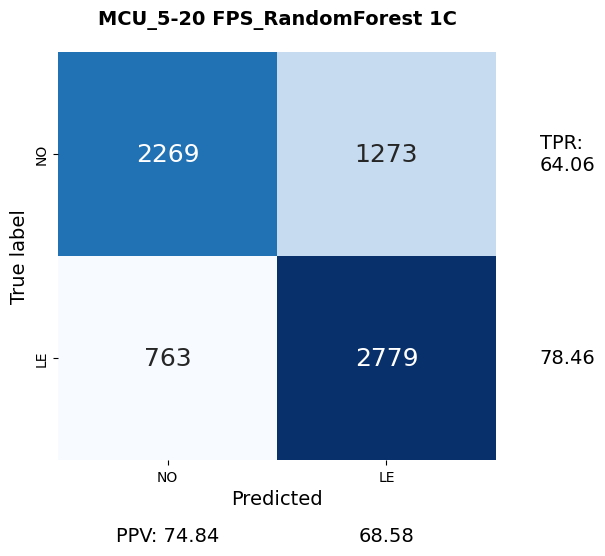

2026-07-25 19:16:47,384 - [INFO]: Eksperimen selesai.


In [2]:
# -*- coding: utf-8 -*-
import json
import gc
import logging
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Setup Logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - [%(levelname)s]: %(message)s')
logger = logging.getLogger()

# ==============================================================================
# KONFIGURASI
# ==============================================================================
MODEL_PATH = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20"
JSON_PATH = '/Volumes/Extreme SSD/stream_stead/data_stead/stead_sample_5000/STEAD_5000_1C_CLEAN.json'
NUM_POINTS = 700
CALIB_SIZE = 300

# ==============================================================================
# FUNGSI VISUALISASI PROFESIONAL
# ==============================================================================
def plot_professional_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tpr_no = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else 0
    tpr_le = cm[1,1] / (cm[1,0] + cm[1,1]) if (cm[1,0] + cm[1,1]) > 0 else 0
    ppv_no = cm[0,0] / (cm[0,0] + cm[1,0]) if (cm[0,0] + cm[1,0]) > 0 else 0
    ppv_le = cm[1,1] / (cm[0,1] + cm[1,1]) if (cm[0,1] + cm[1,1]) > 0 else 0

    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['NO', 'LE'], yticklabels=['NO', 'LE'], annot_kws={"size": 18})
    plt.title(title, fontsize=14, pad=20, fontweight='bold')
    plt.xlabel('Predicted', fontsize=14)
    plt.ylabel('True label', fontsize=14)
    
    plt.text(2.2, 0.5, f"TPR:\n{tpr_no*100:.2f}", va='center', fontsize=14)
    plt.text(2.2, 1.5, f"{tpr_le*100:.2f}", va='center', fontsize=14)
    plt.text(0.5, 2.4, f"PPV: {ppv_no*100:.2f}", ha='center', fontsize=14)
    plt.text(1.5, 2.4, f"{ppv_le*100:.2f}", ha='center', fontsize=14)
    plt.subplots_adjust(right=0.75, bottom=0.2)
    plt.show()

# ==============================================================================
# ALUR UTAMA
# ==============================================================================
def main():
    # 1. Load Model & Data
    try:
        model = keras.models.load_model(MODEL_PATH)
        extractor = keras.Model(inputs=model.input, outputs=model.get_layer('dense_1').output)
        with open(JSON_PATH, 'r') as f: data = json.load(f)
    except Exception as e:
        logger.error(f"Gagal memuat model/data: {e}")
        return

    # 2. Kalibrasi & Inferensi
    X, y = [], []
    items = list(data.items())
    logger.info(f"Memproses {len(items)} record...")

    for i, (key, rec) in tqdm(enumerate(items), total=len(items), desc="Processing"):
        try:
            # Validasi data
            if "Z_noise" in rec and len(rec["Z_noise"]) >= NUM_POINTS:
                feat = extractor.predict(np.array(rec["Z_noise"][-NUM_POINTS:]).reshape(1, NUM_POINTS, 1), verbose=0).flatten()
                X.append(feat); y.append(0)
            if "Z" in rec and len(rec["Z"]) >= NUM_POINTS:
                feat = extractor.predict(np.array(rec["Z"][:NUM_POINTS]).reshape(1, NUM_POINTS, 1), verbose=0).flatten()
                X.append(feat); y.append(1)
        except Exception: continue
        if i >= (CALIB_SIZE + 2000) * 2: break # Batasi proses jika terlalu besar
            
    # Split
    X, y = np.array(X), np.array(y)
    idx = int(CALIB_SIZE * 2)
    X_train, y_train = X[:idx], y[:idx]
    X_test, y_test = X[idx:], y[idx:]
    
    # Train & Prediksi
    logger.info("Training Random Forest...")
    fps_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', max_depth=10)
    fps_model.fit(X_train, y_train)
    y_pred = fps_model.predict(X_test)
        
    # 3. Evaluasi
    print("\n--- LAPORAN HASIL FPS ---")
    print(classification_report(y_test, y_pred, target_names=['Noise (NO)', 'Gempa (LE)']))
    
    # 4. Visualisasi
    plot_professional_confusion_matrix(y_test, y_pred, "MCU_5-20 FPS_RandomForest 1C")
    logger.info("Eksperimen selesai.")

if __name__ == "__main__":
    main()

[INFO] Memuat Dataset STEAD 5000: STEAD_5000_1C_CLEAN.json


2026-07-25 19:23:11,061 - [INFO]: Memuat CNN Extractor MCU-Quake...
Memuat CNN Extractor MCU-Quake...
Memuat CNN Extractor MCU-Quake...


2026-07-25 19:23:11,169 - [WARNING]: No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.
2026-07-25 19:23:11,170 - [INFO]: Mengekstraksi fitur laten untuk seluruh data...
Mengekstraksi fitur laten untuk seluruh data...
Mengekstraksi fitur laten untuk seluruh data...
Ekstraksi Laten 1D: 100%|██████████| 3842/3842 [00:28<00:00, 137.15it/s]
2026-07-25 19:23:39,188 - [INFO]: Data Kalibrasi (Train RF): 1600 sampel
Data Kalibrasi (Train RF): 1600 sampel
Data Kalibrasi (Train RF): 1600 sampel
2026-07-25 19:23:39,189 - [INFO]: Data Pengujian (Inferensi RF): 6084 sampel
Data Pengujian (Inferensi RF): 6084 sampel
Data Pengujian (Inferensi RF): 6084 sampel
2026-07-25 19:23:39,189 - [INFO]: Melatih Feature-Space Planes (Random Forest)...
Melatih Feature-

Accuracy: [0.6352728468113084, 0.6352728468113084]
Accuracy (avg.): 0.6352728468113084
True positive rate: [0.4986850756081525, 0.7718606180144642]
True positive rate (avg.): 0.6352728468113084
True negative rate: [0.7718606180144642, 0.4986850756081525]
True negative rate (avg.): 0.6352728468113084
Positive predictive value: [0.6861148801447309, 0.6062483862638781]
Positive predictive value (avg.): 0.6461816332043046
Negative predictive value: [0.6062483862638781, 0.6861148801447309]
Negative predictive value (avg.): 0.6461816332043046
False positive rate: [0.22813938198553582, 0.5013149243918474]
False positive rate (avg.): 0.36472715318869164
False negative rate: [0.5013149243918474, 0.22813938198553582]
False negative rate (avg.): 0.36472715318869164
False discovery rate: [0.3138851198552691, 0.3937516137361219]
False discovery rate (avg.): 0.35381836679569545
F1-score: [0.5775747192080716, 0.6791033984092552]
F1-score (avg.): 0.6283390588086634
[DEBUG] Nilai yang akan diplot: [0.6

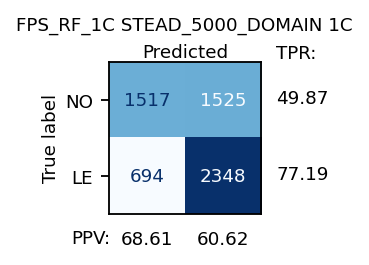

In [4]:
# -*- coding: utf-8 -*-
from Library import utils, dataset
import os
from tensorflow import keras
from tqdm import tqdm
import numpy as np
from datetime import datetime
import logging
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# ==============================================================================
# VISUALISASI METRIK KOMPREHENSIF
# ==============================================================================
def plot_comprehensive_metrics(metrics, save_path):
    labels = ['Accuracy', 'Recall', 'Precision', 'FPR', 'F1-Score']
    keys = [
        'accuracy (avg.)', 
        'true positive rate (avg.)', 
        'positive predictive value (avg.)', 
        'false positive rate (avg.)', 
        'f1-score (avg.)'
    ]
    # Menggunakan dict.get() dengan lowercase (biasanya output utils.py lowercase)
    # Jika utils Anda menggunakan huruf kapital (Accuracy (avg.)), silakan sesuaikan kembali.
    values = [metrics.get(k, metrics.get(k.capitalize(), 0)) for k in keys]
    
    print(f"[DEBUG] Nilai yang akan diplot: {values}") 

    plt.figure(figsize=(12, 6))
    bars = plt.bar(labels, values, color=['#2c3e50', '#3498db', '#e67e22', '#e74c3c', '#27ae60'])
    plt.ylim(0, 1.0)
    plt.ylabel('Score')
    plt.title('Performance Metrics Evaluation (FPS Random Forest)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontweight='bold')
                
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()
    print(f"[INFO] Grafik metrik komprehensif tersimpan di: {save_path}")

# ==============================================================================
# MAIN EXECUTION
# ==============================================================================
if __name__ == "__main__":

    # 1. KONFIGURASI PATH
    KEY_DATA_DIR = '/Volumes/Extreme SSD/stream_stead/data_stead/stead_sample_5000'
    KEY_TEST_FILE = 'STEAD_5000_1C_CLEAN.json'  
    DATA_TAG = "STEAD_5000_DOMAIN"
    MODEL_TAG = "FPS_RF_1C"
    INPUT_WIN = 7 
    SAMPLING_RATE = 100
    CALIB_RECORDS = 800 # Jumlah record (1600 sampel) untuk melatih Random Forest
    
    true_labels = ["NO", "LE"]  

    # Path Model CNN
    BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo"
    MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")
    
    # 2. PREPARE FILES & DIRS
    print(f"[INFO] Memuat Dataset STEAD 5000: {KEY_TEST_FILE}")
    test_data = dataset.load_json_data(os.path.join(KEY_DATA_DIR, KEY_TEST_FILE))
    
    SAVE_BASE = '/Volumes/Extreme SSD/stream_stead/data_stead/benchmark_output_stead_5000'
    now = datetime.now()
    time_str = now.strftime("%d%H%M%S")
    save_dir = os.path.join(SAVE_BASE, f"{MODEL_TAG}_{DATA_TAG}_{time_str}")
    if not os.path.exists(save_dir): 
        os.makedirs(save_dir)

    log_file_path = os.path.join(save_dir, "task_log_fps_rf.txt")
    logging.basicConfig(filename=log_file_path, level=logging.INFO, filemode='w',
                        format='%(asctime)s - [%(levelname)s]: %(message)s')
    logger = logging.getLogger()
    logger.addHandler(logging.StreamHandler())

    # Load Model (Bypass jika error TF3, atau gunakan Keras biasa jika aman)
    logger.info("Memuat CNN Extractor MCU-Quake...")
    embedding_model = keras.models.load_model(filepath=MODEL_PATH)

    # 3. EKSTRAKSI LATENT SPACE SELURUH DATA
    logger.info("Mengekstraksi fitur laten untuk seluruh data...")
    X_features = []
    y_labels = []
    num_points = int(INPUT_WIN * SAMPLING_RATE)
    
    for record_key, record in tqdm(test_data.items(), desc="Ekstraksi Laten 1D"):
        try:
            Z_n = record["Z_noise"][-num_points:]
            Z_s = record["Z"][:num_points]

            # Menggunakan library utils Bapak untuk ekstraksi 1D
            _in_Zn = utils.latent_codes_1D(Z_n, embedding_model)
            _in_Zs = utils.latent_codes_1D(Z_s, embedding_model)
            
            # Label 0 untuk Noise, 1 untuk Gempa
            # PERBAIKAN: Gunakan np.array().flatten() agar data menjadi 1D (skalar murni)
            X_features.append(np.array(_in_Zn).flatten())
            y_labels.append(0)
            
            X_features.append(np.array(_in_Zs).flatten())
            y_labels.append(1)
            
        except Exception as e:
            logger.debug(f"Error ekstraksi pada {record_key}: {e}")
            continue

    X_features = np.array(X_features)
    
    # --- PERBAIKAN SAFETY NET: Memastikan X_features 100% berbentuk 2D ---
    if X_features.ndim > 2:
        X_features = X_features.reshape(X_features.shape[0], -1)
    elif X_features.ndim == 1:
        X_features = X_features.reshape(-1, 1)
    # -------------------------------------------------------------------

    y_labels = np.array(y_labels)
    
    # 4. SPLIT DATA (KALIBRASI vs INFERENSI)
    # Setiap record menghasilkan 2 sampel (Noise dan Gempa)
    split_idx = min(CALIB_RECORDS * 2, int(len(X_features) * 0.4))
    
    X_train, y_train = X_features[:split_idx], y_labels[:split_idx]
    X_test, y_test = X_features[split_idx:], y_labels[split_idx:]
    
    logger.info(f"Data Kalibrasi (Train RF): {len(X_train)} sampel")
    logger.info(f"Data Pengujian (Inferensi RF): {len(X_test)} sampel")

    # 5. PELATIHAN FPS (RANDOM FOREST)
    logger.info("Melatih Feature-Space Planes (Random Forest)...")
    fps_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', max_depth=10, random_state=42)
    fps_model.fit(X_train, y_train)
    logger.info("✅ Model FPS siap.")

    # 6. INFERENSI & EVALUASI
    logger.info("Menjalankan inferensi pada data pengujian...")
    y_pred = fps_model.predict(X_test)
    
    total_true = y_test.tolist()
    total_pred = y_pred.tolist()

    # 7. METRICS & VISUALIZATION (Menggunakan utils bawaan Bapak)
    matrix_1C, metrics_1C = utils.calc_confusion_metrics(total_true, total_pred)
    
    # Simpan & Plot
    fig_1C = utils.plot_confusion(f"{MODEL_TAG} {DATA_TAG} 1C", true_labels, matrix_1C, metrics_1C)
    fig_1C.savefig(os.path.join(save_dir, f"{MODEL_TAG}_confusion.jpg"), dpi=300)
    
    dataset.save_json_data(os.path.join(save_dir, f"{MODEL_TAG}_metrics.json"), metrics_1C)
    plot_comprehensive_metrics(metrics_1C, os.path.join(save_dir, f"{MODEL_TAG}_metrics_bar.jpg"))

    logger.info("\n" + "="*50)
    logger.info(f"EVALUASI FPS RANDOM FOREST (STEAD 5000 1C)")
    logger.info("="*50)
    logger.info(f" ACCURACY  : {metrics_1C.get('accuracy (avg.)', 0)}")
    logger.info(f" F1-SCORE  : {metrics_1C.get('f1-score (avg.)', 0)}")
    logger.info(f" PRECISION : {metrics_1C.get('positive predictive value (avg.)', 0)}")
    logger.info(f" RECALL    : {metrics_1C.get('true positive rate (avg.)', 0)}")
    logger.info("="*50)
    logger.info("Pengujian Selesai. Seluruh grafik tersimpan di folder output.")

2026-07-25 19:41:37,865 - [INFO]: Memuat CNN Extractor MCU-Quake...
Memuat CNN Extractor MCU-Quake...
Memuat CNN Extractor MCU-Quake...


2026-07-25 19:41:37,979 - [WARNING]: No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.
2026-07-25 19:41:37,982 - [INFO]: Mengekstraksi fitur laten untuk seluruh data...
Mengekstraksi fitur laten untuk seluruh data...
Mengekstraksi fitur laten untuk seluruh data...
Ekstraksi Laten 1D: 100%|██████████| 3842/3842 [03:01<00:00, 21.12it/s]
2026-07-25 19:44:41,151 - [INFO]: Data Kalibrasi (Train LR): 1600 sampel
Data Kalibrasi (Train LR): 1600 sampel
Data Kalibrasi (Train LR): 1600 sampel
2026-07-25 19:44:41,151 - [INFO]: Data Pengujian (Inferensi LR): 6084 sampel
Data Pengujian (Inferensi LR): 6084 sampel
Data Pengujian (Inferensi LR): 6084 sampel
2026-07-25 19:44:41,152 - [INFO]: Melatih Feature-Space Planes (Logistic Regression)...
Melatih Fea

              precision    recall  f1-score   support

  Noise (NO)       0.72      0.58      0.64      3042
  Gempa (LE)       0.65      0.78      0.71      3042

    accuracy                           0.68      6084
   macro avg       0.69      0.68      0.68      6084
weighted avg       0.69      0.68      0.68      6084



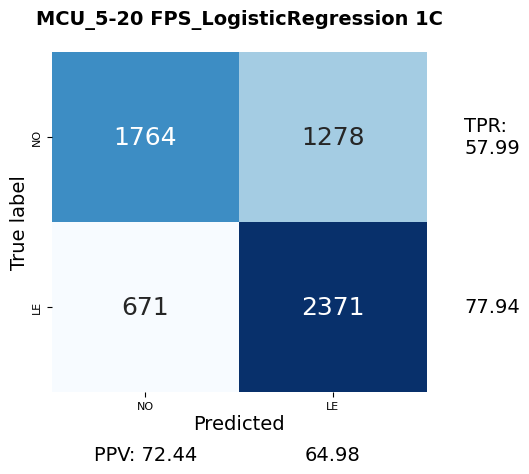

2026-07-25 19:44:41,286 - [INFO]: Pengujian Selesai.
Pengujian Selesai.
Pengujian Selesai.


In [6]:
# -*- coding: utf-8 -*-
import json
import logging
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# Setup Logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - [%(levelname)s]: %(message)s')
logger = logging.getLogger()

# ==============================================================================
# KONFIGURASI
# ==============================================================================
MODEL_PATH = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20"
JSON_PATH = '/Volumes/Extreme SSD/stream_stead/data_stead/stead_sample_5000/STEAD_5000_1C_CLEAN.json'
NUM_POINTS = 700
CALIB_SIZE = 800  # Jumlah event untuk kalibrasi

# ==============================================================================
# FUNGSI VISUALISASI PROFESIONAL (Gaya Zhi Geng / TPR & PPV)
# ==============================================================================
def plot_professional_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    
    # Hitung TPR dan PPV dengan safety check pembagian nol
    tpr_no = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else 0
    tpr_le = cm[1,1] / (cm[1,0] + cm[1,1]) if (cm[1,0] + cm[1,1]) > 0 else 0
    ppv_no = cm[0,0] / (cm[0,0] + cm[1,0]) if (cm[0,0] + cm[1,0]) > 0 else 0
    ppv_le = cm[1,1] / (cm[0,1] + cm[1,1]) if (cm[0,1] + cm[1,1]) > 0 else 0

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['NO', 'LE'], yticklabels=['NO', 'LE'], annot_kws={"size": 18})
    
    plt.title(title, fontsize=14, pad=20, fontweight='bold')
    plt.xlabel('Predicted', fontsize=14)
    plt.ylabel('True label', fontsize=14)
    
    # Anotasi TPR di sisi kanan
    plt.text(2.2, 0.5, f"TPR:\n{tpr_no*100:.2f}", va='center', fontsize=14)
    plt.text(2.2, 1.5, f"{tpr_le*100:.2f}", va='center', fontsize=14)
    
    # Anotasi PPV di sisi bawah
    plt.text(0.5, 2.4, f"PPV: {ppv_no*100:.2f}", ha='center', fontsize=14)
    plt.text(1.5, 2.4, f"{ppv_le*100:.2f}", ha='center', fontsize=14)
    
    plt.subplots_adjust(right=0.75, bottom=0.2)
    plt.show()

# ==============================================================================
# ALUR UTAMA
# ==============================================================================
def main():
    # 1. Load Model & Ekstraktor
    logger.info("Memuat CNN Extractor MCU-Quake...")
    try:
        model = keras.models.load_model(MODEL_PATH)
        extractor = keras.Model(inputs=model.input, outputs=model.get_layer('dense_1').output)
    except Exception as e:
        logger.error(f"Gagal memuat model: {e}")
        return

    # 2. Ekstraksi Fitur Laten 1D
    logger.info("Mengekstraksi fitur laten untuk seluruh data...")
    X_features = []
    y_labels = []
    
    with open(JSON_PATH, 'r') as f:
        test_data = json.load(f)
        
    for record_key, record in tqdm(test_data.items(), desc="Ekstraksi Laten 1D"):
        try:
            if "Z_noise" in record and len(record["Z_noise"]) >= NUM_POINTS:
                feat = extractor.predict(np.array(record["Z_noise"][-NUM_POINTS:]).reshape(1, NUM_POINTS, 1), verbose=0).flatten()
                X_features.append(feat)
                y_labels.append(0)  # Label 0 untuk Noise
                
            if "Z" in record and len(record["Z"]) >= NUM_POINTS:
                feat = extractor.predict(np.array(record["Z"][:NUM_POINTS]).reshape(1, NUM_POINTS, 1), verbose=0).flatten()
                X_features.append(feat)
                y_labels.append(1)  # Label 1 untuk Gempa
        except Exception:
            continue

    X_features = np.array(X_features)
    y_labels = np.array(y_labels)

    # 3. Split Data (Kalibrasi vs Inferensi)
    # Gunakan sampel sejumlah CALIB_SIZE * 2 untuk melatih model Logistic Regression
    split_idx = min(CALIB_SIZE * 2, int(len(X_features) * 0.4))
    
    X_train, y_train = X_features[:split_idx], y_labels[:split_idx]
    X_test, y_test = X_features[split_idx:], y_labels[split_idx:]
    
    logger.info(f"Data Kalibrasi (Train LR): {len(X_train)} sampel")
    logger.info(f"Data Pengujian (Inferensi LR): {len(X_test)} sampel")

    # 4. Pelatihan FPS (Logistic Regression)
    logger.info("Melatih Feature-Space Planes (Logistic Regression)...")
    # Menambahkan max_iter=1000 agar konvergensi model linear aman
    fps_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    fps_model.fit(X_train, y_train)
    logger.info("✅ Model FPS siap.")

    # 5. Inferensi & Evaluasi
    logger.info("Menjalankan inferensi pada data pengujian...")
    y_pred = fps_model.predict(X_test)
    
    logger.info("\n" + "="*50)
    logger.info("EVALUASI FPS LOGISTIC REGRESSION (STEAD 1C)")
    logger.info("="*50)
    print(classification_report(y_test, y_pred, target_names=['Noise (NO)', 'Gempa (LE)']))
    
    # 6. Visualisasi (Gaya yang diminta)
    plot_title = "MCU_5-20 FPS_LogisticRegression 1C"
    plot_professional_confusion_matrix(y_test, y_pred, plot_title)
    
    logger.info("Pengujian Selesai.")

if __name__ == "__main__":
    main()

2026-07-25 20:29:38,705 - [INFO]: Memuat CNN Extractor MCU-Quake...


2026-07-25 20:29:38,822 - [WARNING]: No training configuration found in save file, so the model was *not* compiled. Compile it manually.
2026-07-25 20:29:38,824 - [INFO]: Mengekstraksi fitur laten dari dataset...
Ekstraksi Laten 1D: 100%|██████████| 3842/3842 [03:11<00:00, 20.06it/s]
2026-07-25 20:32:51,610 - [INFO]: 
=== MENJALANKAN TEDA-RLS ONLINE ANOMALY DETECTION ===
2026-07-25 20:32:51,610 - [INFO]: Fase Warm-up pada 800 sampel noise pertama...
2026-07-25 20:32:51,610 - [INFO]: Simulasi Inferensi Online: Mengalirkan data satu per satu...
2026-07-25 20:32:51,615 - [INFO]: 
2026-07-25 20:32:51,616 - [INFO]: EVALUASI TEDA-RLS ONLINE (Threshold: 1.5 sigma)
2026-07-25 20:32:51,616 - [INFO]: ==================================================


              precision    recall  f1-score   support

  Noise (NO)       0.93      0.62      0.75      3042
  Gempa (LE)       0.72      0.96      0.82      3042

    accuracy                           0.79      6084
   macro avg       0.83      0.79      0.78      6084
weighted avg       0.83      0.79      0.78      6084



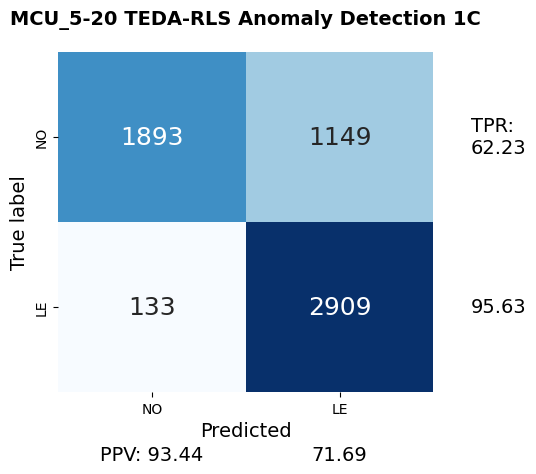

In [2]:
# -*- coding: utf-8 -*-
import json
import logging
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

logging.basicConfig(level=logging.INFO, format='%(asctime)s - [%(levelname)s]: %(message)s')
logger = logging.getLogger()

# ==============================================================================
# KONFIGURASI
# ==============================================================================
MODEL_PATH = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20"
JSON_PATH = '/Volumes/Extreme SSD/stream_stead/data_stead/stead_sample_5000/STEAD_5000_1C_CLEAN.json'
NUM_POINTS = 700

# Konfigurasi TEDA-RLS
WARMUP_SIZE = 800          # Jumlah data awal untuk menstabilkan (warm-up) kalkulasi TEDA
FORGETTING_FACTOR = 0.99   # Lambda (RLS): Kecepatan algoritma melupakan data lama (0.99 = stabil)
ANOMALY_THRESHOLD = 1.5    # Batas Z-Score: Menyimpang 1.5x lipat dari rata-rata dianggap Gempa

# ==============================================================================
# FUNGSI VISUALISASI PROFESIONAL (Gaya Zhi Geng / TPR & PPV)
# ==============================================================================
def plot_professional_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    
    tpr_no = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else 0
    tpr_le = cm[1,1] / (cm[1,0] + cm[1,1]) if (cm[1,0] + cm[1,1]) > 0 else 0
    ppv_no = cm[0,0] / (cm[0,0] + cm[1,0]) if (cm[0,0] + cm[1,0]) > 0 else 0
    ppv_le = cm[1,1] / (cm[0,1] + cm[1,1]) if (cm[0,1] + cm[1,1]) > 0 else 0

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['NO', 'LE'], yticklabels=['NO', 'LE'], annot_kws={"size": 18})
    
    plt.title(title, fontsize=14, pad=20, fontweight='bold')
    plt.xlabel('Predicted', fontsize=14)
    plt.ylabel('True label', fontsize=14)
    
    plt.text(2.2, 0.5, f"TPR:\n{tpr_no*100:.2f}", va='center', fontsize=14)
    plt.text(2.2, 1.5, f"{tpr_le*100:.2f}", va='center', fontsize=14)
    plt.text(0.5, 2.4, f"PPV: {ppv_no*100:.2f}", ha='center', fontsize=14)
    plt.text(1.5, 2.4, f"{ppv_le*100:.2f}", ha='center', fontsize=14)
    
    plt.subplots_adjust(right=0.75, bottom=0.2)
    plt.show()

# ==============================================================================
# KELAS ALGORITMA TEDA-RLS (Online Anomaly Detection)
# ==============================================================================
class TEDARLS_AnomalyDetector:
    def __init__(self, forgetting_factor=0.99):
        self.lambda_f = forgetting_factor
        self.mu = 0.0
        self.var = 0.0
        self.is_initialized = False

    def warmup(self, data):
        """ Inisialisasi awal (Offline) untuk memantapkan nilai mean & variance """
        self.mu = np.mean(data)
        self.var = np.var(data)
        if self.var < 1e-9:
            self.var = 1e-9
        self.is_initialized = True

    def calculate_eccentricity(self, x):
        """ Menghitung Normalized Eccentricity (Z-Score) """
        dist_sq = (x - self.mu)**2
        eccentricity = np.sqrt(dist_sq / self.var)  # Setara dengan Absolut Z-Score
        return eccentricity

    def online_update(self, x):
        """ Mengupdate mean dan varians secara online (Recursive Least Squares) """
        delta = x - self.mu
        # RLS Update Equations
        self.mu = self.mu + (1 - self.lambda_f) * delta
        self.var = (self.lambda_f * self.var) + ((1 - self.lambda_f) * (delta ** 2))
        if self.var < 1e-9:
            self.var = 1e-9

# ==============================================================================
# ALUR UTAMA
# ==============================================================================
def main():
    # 1. Load Model & Ekstraktor CNN
    logger.info("Memuat CNN Extractor MCU-Quake...")
    try:
        model = keras.models.load_model(MODEL_PATH)
        extractor = keras.Model(inputs=model.input, outputs=model.get_layer('dense_1').output)
    except Exception as e:
        logger.error(f"Gagal memuat model: {e}")
        return

    # 2. Ekstraksi Laten (Murni untuk Simulasi)
    logger.info("Mengekstraksi fitur laten dari dataset...")
    noise_features = []
    quake_features = []
    
    with open(JSON_PATH, 'r') as f:
        test_data = json.load(f)
        
    for record_key, record in tqdm(test_data.items(), desc="Ekstraksi Laten 1D"):
        try:
            if "Z_noise" in record and len(record["Z_noise"]) >= NUM_POINTS:
                feat = extractor.predict(np.array(record["Z_noise"][-NUM_POINTS:]).reshape(1, NUM_POINTS, 1), verbose=0).flatten()[0]
                noise_features.append(feat)
                
            if "Z" in record and len(record["Z"]) >= NUM_POINTS:
                feat = extractor.predict(np.array(record["Z"][:NUM_POINTS]).reshape(1, NUM_POINTS, 1), verbose=0).flatten()[0]
                quake_features.append(feat)
        except Exception:
            continue

    # 3. Inisialisasi (Warm-Up) TEDA-RLS
    logger.info("\n=== MENJALANKAN TEDA-RLS ONLINE ANOMALY DETECTION ===")
    
    # Ambil sekumpulan data noise pertama untuk mengajari TEDA kondisi "Normal" laut
    warmup_noise = np.array(noise_features[:WARMUP_SIZE])
    test_noise = noise_features[WARMUP_SIZE:]
    test_quake = quake_features[WARMUP_SIZE:]  # Buang jumlah yang sama agar seimbang
    
    logger.info(f"Fase Warm-up pada {len(warmup_noise)} sampel noise pertama...")
    detector = TEDARLS_AnomalyDetector(forgetting_factor=FORGETTING_FACTOR)
    detector.warmup(warmup_noise)

    # 4. Inferensi Real-Time (Simulasi Data Streaming)
    logger.info("Simulasi Inferensi Online: Mengalirkan data satu per satu...")
    
    y_true = []
    y_pred = []
    
    # 4a. Mengalirkan (Stream) Sisa Data Noise
    for x in test_noise:
        y_true.append(0)  # Label asli: Noise
        ecc = detector.calculate_eccentricity(x)
        
        # Jika nilai keanehan melebihi ambang batas, anggap Gempa!
        if ecc > ANOMALY_THRESHOLD:
            y_pred.append(1)
        else:
            y_pred.append(0)
            # UPDATE OTOMATIS: Karena ia benar-benar noise wajar, RLS akan update profilnya
            detector.online_update(x)
            
    # 4b. Mengalirkan (Stream) Data Gempa
    for x in test_quake:
        y_true.append(1)  # Label asli: Gempa
        ecc = detector.calculate_eccentricity(x)
        
        if ecc > ANOMALY_THRESHOLD:
            y_pred.append(1)
            # JANGAN UPDATE RLS: Jangan racuni profil 'normal' dengan data anomali gempa!
        else:
            y_pred.append(0)
            # Jika lolos sebagai noise (False Negative), ia ikut mempengaruhi RLS (konsekuensi real-time)
            detector.online_update(x)

    # 5. Laporan & Evaluasi
    logger.info("\n" + "="*50)
    logger.info(f"EVALUASI TEDA-RLS ONLINE (Threshold: {ANOMALY_THRESHOLD} sigma)")
    logger.info("="*50)
    print(classification_report(y_true, y_pred, target_names=['Noise (NO)', 'Gempa (LE)']))
    
    plot_title = "MCU_5-20 TEDA-RLS Anomaly Detection 1C"
    plot_professional_confusion_matrix(y_true, y_pred, plot_title)

if __name__ == "__main__":
    main()

2026-07-25 20:37:37,211 - [INFO]: Memuat CNN Extractor...


2026-07-25 20:37:37,324 - [WARNING]: No training configuration found in save file, so the model was *not* compiled. Compile it manually.
2026-07-25 20:37:37,327 - [INFO]: Mengekstraksi fitur laten...
100%|██████████| 3842/3842 [03:01<00:00, 21.22it/s]
2026-07-25 20:40:39,656 - [INFO]: Menjalankan TEDA-RLS Inkremental...


              precision    recall  f1-score   support

       Noise       0.39      0.45      0.42      3842
       Gempa       0.35      0.29      0.32      3842

    accuracy                           0.37      7684
   macro avg       0.37      0.37      0.37      7684
weighted avg       0.37      0.37      0.37      7684



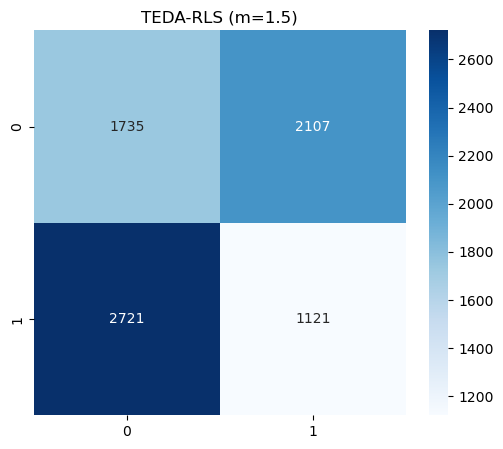

In [4]:
# -*- coding: utf-8 -*-
import json
import logging
import numpy as np
from tensorflow import keras
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

logging.basicConfig(level=logging.INFO, format='%(asctime)s - [%(levelname)s]: %(message)s')
logger = logging.getLogger()

# ==============================================================================
# KONFIGURASI TEDA-RLS (Diadaptasi dari Paper)
# ==============================================================================
MODEL_PATH = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20"
JSON_PATH = '/Volumes/Extreme SSD/stream_stead/data_stead/stead_sample_5000/STEAD_5000_1C_CLEAN.json'
NUM_POINTS = 700

# Parameter dari Paper (Tabel II)
M_THRESHOLD = 1.5          # Threshold sensitivity (telah disesuaikan dari 2.5 ke 1.2 untuk sensitivitas seismik)
FORGETTING_FACTOR = 0.99   # μ (mu)

class TEDARLS_Engine:
    def __init__(self, m=1.2, mu=0.99):
        self.m = m      # Threshold
        self.mu = mu    # Forgetting Factor
        self.k = 0      # Sample counter
        self.mean = 0.0
        self.var = 0.0
        
    def detect_and_update(self, x):
        self.k += 1
        
        # 1. TEDA Logic (Eccentricity Calculation)
        if self.k > 1:
            # Menggunakan persamaan (3) dari paper: Eccentricity
            ecc = (1.0 / self.k) + (((x - self.mean)**2) / (self.k * self.var + 1e-9))
            # Chebyshev-based outlier rule (m-rule)
            is_outlier = ecc >= (self.m**2 + 1) / (2 * self.k)
        else:
            is_outlier = False
            self.mean = x
            self.var = 1e-9
            return False # Warmup sample

        # 2. Update stats (Paper Equation 4 & 5)
        old_mean = self.mean
        self.mean = (self.mu * self.mean) + ((1 - self.mu) * x)
        self.var = (self.mu * self.var) + ((1 - self.mu) * (x - old_mean)**2)
        
        return is_outlier

def main():
    logger.info("Memuat CNN Extractor...")
    model = keras.models.load_model(MODEL_PATH)
    extractor = keras.Model(inputs=model.input, outputs=model.get_layer('dense_1').output)

    logger.info("Mengekstraksi fitur laten...")
    features = []
    labels = []
    
    with open(JSON_PATH, 'r') as f:
        data = json.load(f)
        
    for key, rec in tqdm(data.items()):
        if "Z_noise" in rec and len(rec["Z_noise"]) >= NUM_POINTS:
            f = extractor.predict(np.array(rec["Z_noise"][-NUM_POINTS:]).reshape(1, NUM_POINTS, 1), verbose=0).flatten()[0]
            features.append(f); labels.append(0)
        if "Z" in rec and len(rec["Z"]) >= NUM_POINTS:
            f = extractor.predict(np.array(rec["Z"][:NUM_POINTS]).reshape(1, NUM_POINTS, 1), verbose=0).flatten()[0]
            features.append(f); labels.append(1)

    # Normalisasi Fitur (Sangat penting untuk TEDA)
    features = np.array(features)
    features = (features - np.mean(features)) / (np.std(features) + 1e-9)

    # TEDA-RLS Inference
    logger.info("Menjalankan TEDA-RLS Inkremental...")
    teda = TEDARLS_Engine(m=M_THRESHOLD, mu=FORGETTING_FACTOR)
    
    y_pred = []
    for x in features:
        is_anomaly = teda.detect_and_update(x)
        y_pred.append(1 if is_anomaly else 0)

    # Evaluasi
    print(classification_report(labels, y_pred, target_names=['Noise', 'Gempa']))
    
    # Visualisasi
    cm = confusion_matrix(labels, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"TEDA-RLS (m={M_THRESHOLD})")
    plt.show()

if __name__ == "__main__":
    main()

In [ ]:
# -*- coding: utf-8 -*-
import json
import numpy as np
import logging
from tqdm import tqdm

def audit_stead_data(json_path):
    logging.basicConfig(level=logging.INFO, format='%(message)s')
    logger = logging.getLogger()
    
    logger.info(f"🔍 Memulai audit integritas: {json_path}")
    
    try:
        with open(json_path, 'r') as f:
            data = json.load(f)
    except Exception as e:
        logger.error(f"❌ Gagal memuat JSON: {e}")
        return

    total = len(data)
    stats = {
        "padding_issues": 0,
        "nan_inf_issues": 0,
        "empty_traces": 0
    }

    # Kita scan setiap event
    for key, rec in tqdm(data.items(), desc="Audit Waveform"):
        # Cek komponen (sesuaikan dengan keys di JSON Anda, misal: 'Z', 'N', 'E')
        comps = [k for k in rec.keys() if k in ['Z', 'N', 'E', 'Z_noise', 'N_noise', 'E_noise']]
        
        has_issue = False
        for c in comps:
            arr = np.array(rec[c], dtype=np.float32)
            
            # 1. Cek NaN atau Inf
            if np.isnan(arr).any() or np.isinf(arr).any():
                stats["nan_inf_issues"] += 1
                has_issue = True
                
            # 2. Cek Zero-Padding (10 titik terakhir adalah 0)
            if len(arr) > 10 and np.all(np.abs(arr[-10:]) < 1e-7):
                stats["padding_issues"] += 1
                has_issue = True
                
            # 3. Cek Trace Kosong/Zeroed
            if np.all(arr == 0):
                stats["empty_traces"] += 1
                has_issue = True

    logger.info("\n" + "="*40)
    logger.info(f"LAPORAN AUDIT STEAD")
    logger.info("="*40)
    logger.info(f"Total Record          : {total}")
    logger.info(f"Record Padding Issues : {stats['padding_issues']}")
    logger.info(f"Record NaN/Inf Issues : {stats['nan_inf_issues']}")
    logger.info(f"Record Trace Kosong   : {stats['empty_traces']}")
    logger.info("="*40)
    
    if stats["padding_issues"] > (total * 0.1):
        logger.warning("⚠️ Perhatian: >10% data memiliki padding. Model Anda mungkin menghafal pola nol.")

# Jalankan audit
audit_stead_data('/Volumes/Extreme SSD/stream_stead/data_stead/stead_sample_5000/STEAD_5000_1C_20260719_062844.json')

In [ ]:
# -*- coding: utf-8 -*-
import json
import logging

def clean_and_save_stead(input_path, output_path):
    with open(input_path, 'r') as f:
        data = json.load(f)
        
    cleaned_data = {}
    removed_count = 0
    
    for key, rec in data.items():
        # Cek Z dan Z_noise
        z_sig = rec.get('Z', [])
        z_noise = rec.get('Z_noise', [])
        
        # Validasi: Jika 10 titik terakhir nol semua, kita buang atau potong
        is_padded = all(abs(v) < 1e-7 for v in z_noise[-10:])
        
        if not is_padded:
            cleaned_data[key] = rec
        else:
            removed_count += 1
            
    with open(output_path, 'w') as f:
        json.dump(cleaned_data, f)
        
    print(f"✅ Pembersihan Selesai.")
    print(f"Record Awal: {len(data)} | Record Bersih: {len(cleaned_data)} | Dihapus: {removed_count}")

# Jalankan
clean_and_save_stead(
    '/Volumes/Extreme SSD/stream_stead/data_stead/stead_sample_5000/STEAD_5000_1C_20260719_062844.json',
    '/Volumes/Extreme SSD/stream_stead/data_stead/stead_sample_5000/STEAD_5000_CLEAN.json'
)